In [1]:
# build large-scale data in scBank format from a group of AnnData objects
# %%
import gc
import json
from pathlib import Path
import argparse
import shutil
import traceback
from typing import Dict, List, Optional
import warnings
import numpy as np
import os
import anndata

import scanpy as sc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


from typing import Any, Dict, List, Mapping, Optional, Tuple, Union
from typing_extensions import Self, Literal
from scipy.sparse import issparse

import matplotlib as mpl
def set_vis_default(font = 1.6, circle_marker = 1.):
    mpl.rcParams['font.family'] = 'Arial'
    plt.rcParams.update(plt.rcParamsDefault)
#     %matplotlib inline
    try:
        plt.style.use('seaborn-whitegrid')
    except:
        plt.style.use('seaborn-v0_8-whitegrid')

    sns.set_context('paper',font_scale=font)
    plt.rcParams["legend.markerscale"] = circle_marker
    mpl.rcParams['font.family'] = 'Arial'



In [18]:
from anndata import AnnData
def subsample_cluster(adata, subsample_col, max_cellnum, max_cellnum_dict = None, verbose = False, show_res = False):
    if isinstance(adata, AnnData):
        df_input = adata.obs.copy()
    elif isinstance(adata, pd.DataFrame):
        df_input = adata.copy()
    tissues = df_input[subsample_col].unique()
    selected_index = []

    for tissue in tissues:
        if max_cellnum_dict is not None:
            max_cellnum = max_cellnum_dict[tissue]
        tissue_index = np.where(df_input[subsample_col] == tissue)[0]
        tissue_cell_num = tissue_index.shape[0]
        if tissue_cell_num > max_cellnum:
            if verbose:
                print(f'tissue {tissue} cell num: {tissue_cell_num}, subsample to 30000')
            tissue_selected_index = np.random.choice(tissue_index, size = max_cellnum, replace = False)
            selected_index.extend(tissue_selected_index)
        else:
            if verbose:
                print(f'tissue {tissue} cell num: {tissue_cell_num}, keep')
            selected_index.extend(tissue_index)


    if isinstance(adata, AnnData):
        adata_subsample = adata[selected_index]
        if show_res:
            print(adata_subsample.obs[subsample_col].value_counts())
    elif isinstance(adata, pd.DataFrame):
        adata_subsample = adata.iloc[selected_index]

        if show_res:
            print(adata_subsample[subsample_col].value_counts())
    return adata_subsample



# Load assigned spatial pseudo time

In [6]:
base_path = '/import/home2/xwanaf/Img2Expr/data/Reproducibility_data/PF'
file_path = Path(base_path) / 'sp_map_to_sc_Epi'

######### saved from Fig2_1_sp_map_to_sc.ipynb
file_name = 'UGE_sp_added_time.h5ad'
adata_sp_time = sc.read(file_path / file_name)

In [7]:
adata_sp_time

AnnData object with n_obs × n_vars = 22854 × 1741
    obs: 'sample', 'patient', 'cell_id', 'sample_type', 'sample_affect', 'disease_status', 'percent_pathology', 'tma', 'run', 'final_CT', 'final_lineage', 'CNiche', 'TNiche', 'lumen_id', 'lumen_rank', 'x_centroid', 'y_centroid', 'adj_x_centroid', 'adj_y_centroid', 'super_adj_x_centroid', 'super_adj_y_centroid', 'nCount_RNA', 'nFeature_RNA', 'perc_negcontrolprobe', 'perc_negcontrolcodeword', 'perc_unassigned', 'perc_negcontrolorunassigned', 'n_genes', 'pred_atlas', 'predict_mapped_ct_anno_prob', 'Slides', 'time'
    obsm: 'X_diffmap'

# Load nrb expr data

Please run ./spatial_nrb_src/get_nrb_expr.sh first

### Expr of neighbor FB_ECM

In [41]:
nrb_expr_path = './spatial_nrb_src/output'
nrb_expr_path = Path(nrb_expr_path)
os.listdir(nrb_expr_path)

adata_nrb = sc.read(nrb_expr_path / 'nrb_expr_raw_FB_ECM.h5ad')


In [42]:
adata_nrb_index = adata_nrb.obs.index[adata_nrb.obs.index.isin(adata_sp_time.obs.index)]
adata_nrb = adata_nrb[adata_nrb_index].copy()
adata_nrb.obs['time'] = adata_sp_time.obs.loc[adata_nrb.obs.index]['time']
adata_nrb.obsm['X_diffmap'] = adata_sp_time[adata_nrb.obs.index].obsm['X_diffmap']
adata_nrb

AnnData object with n_obs × n_vars = 14984 × 337
    obs: 'sample', 'nrb_ct', 'time'
    obsm: 'X_diffmap'

# Divide stages

/tmp/ipykernel_3454798/1900002615.py:31: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')
/tmp/ipykernel_3454798/1503429715.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('Spectral').reversed()


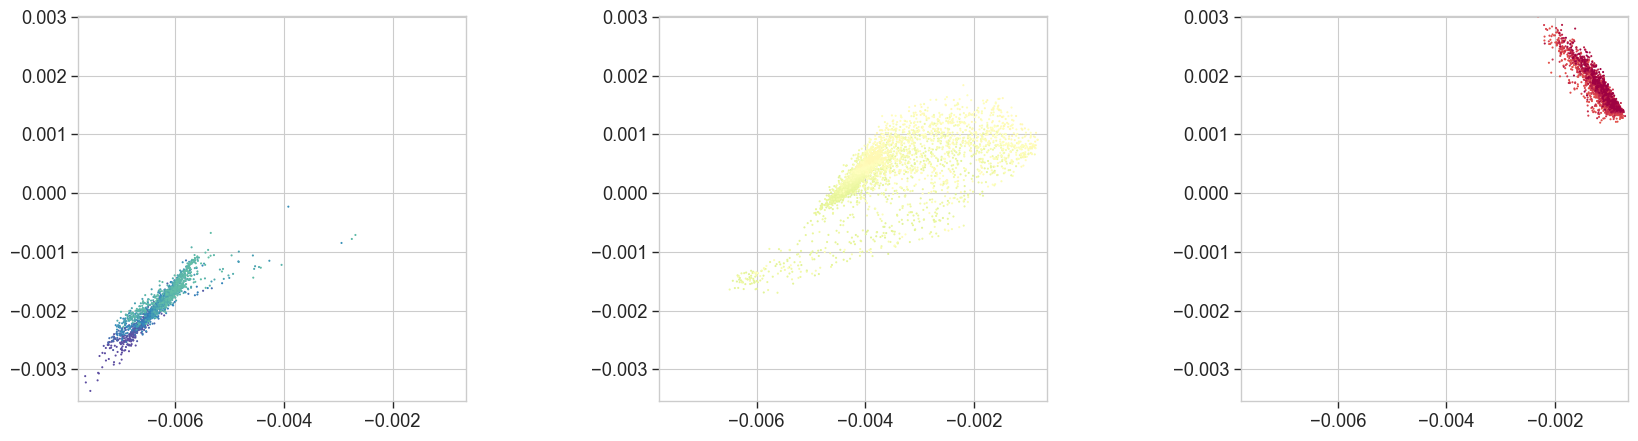

In [43]:
from matplotlib import cm

set_vis_default(font = 1.5)

fig, axs = plt.subplots(1, 3, figsize=(20, 5), gridspec_kw={'wspace': .5, 'hspace': 0.2})
X_diffmap_vis = adata_sp_time.obsm['X_diffmap'][:, [1,2]]
reorder_index = np.argsort(adata_sp_time.obs['time'])

# float_values = adata_sp_time[:, 'ICAM1'].X.A.squeeze()
float_values = adata_sp_time.obs['time']
# cmap = cm.get_cmap('viridis')
cmap = cm.get_cmap('Spectral').reversed()
norm = plt.Normalize(vmin=0.26, vmax=np.quantile(float_values, .99))
colors = cmap(norm(float_values))

index = reorder_index

time_index = (adata_sp_time.obs['time'] <= .35)[reorder_index] #& (adata_sp_time.obs['time'] >= 0.6)
Early_index = adata_sp_time[reorder_index][time_index].obs.index
axs[0].scatter(
    X_diffmap_vis[index][:, 0][time_index], X_diffmap_vis[index][:, 1][time_index], 
    s = .5, color=colors[index][time_index]
) 
time_index = ((adata_sp_time.obs['time'] > .44) & (adata_sp_time.obs['time'] < .5))[reorder_index] #& (adata_sp_time.obs['time'] >= 0.6)
Median_index = adata_sp_time[reorder_index][time_index].obs.index
axs[1].scatter(
    X_diffmap_vis[index][:, 0][time_index], X_diffmap_vis[index][:, 1][time_index], 
    s = .5, color=colors[index][time_index]
)
time_index = (adata_sp_time.obs['time'] > .65)[reorder_index] #& (adata_sp_time.obs['time'] >= 0.6)
Late_index = adata_sp_time[reorder_index][time_index].obs.index
axs[2].scatter(
    X_diffmap_vis[index][:, 0][time_index], X_diffmap_vis[index][:, 1][time_index], 
    s = .5, color=colors[index][time_index]
)

for i in range(3):
    axs[i].set_xlim([X_diffmap_vis[:, 0].min(), X_diffmap_vis[:, 0].max()])
    axs[i].set_ylim([X_diffmap_vis[:, 1].min(), X_diffmap_vis[:, 1].max()])
plt.show()
plt.close()


In [44]:
adata_scaled = adata_nrb.copy()

###### assign stage label
Group = np.empty(adata_scaled.shape[0], dtype = object)
Group[adata_scaled.obs.index.isin(list(Early_index))] = 'Mild'
Group[adata_scaled.obs.index.isin(list(Median_index))] = 'Moderate'
Group[adata_scaled.obs.index.isin(list(Late_index))] = 'Severe'
adata_scaled.obs['stage'] = Group


# sc.pp.scale(adata_scaled)

In [14]:
adata_scaled.obs['stage'].value_counts()

stage
Moderate    2453
Severe      1584
Mild         831
Name: count, dtype: int64

In [27]:
adata_de = adata_scaled.copy()
adata_de = subsample_cluster(
    adata_de, 
    subsample_col = 'stage', 
    max_cellnum = 100,
    show_res = True
).copy()

stage
Moderate    100
Mild        100
Severe      100
Name: count, dtype: int64


         Falling back to preprocessing with `sc.pp.pca` and default params.


/tmp/ipykernel_3454798/1900002615.py:31: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


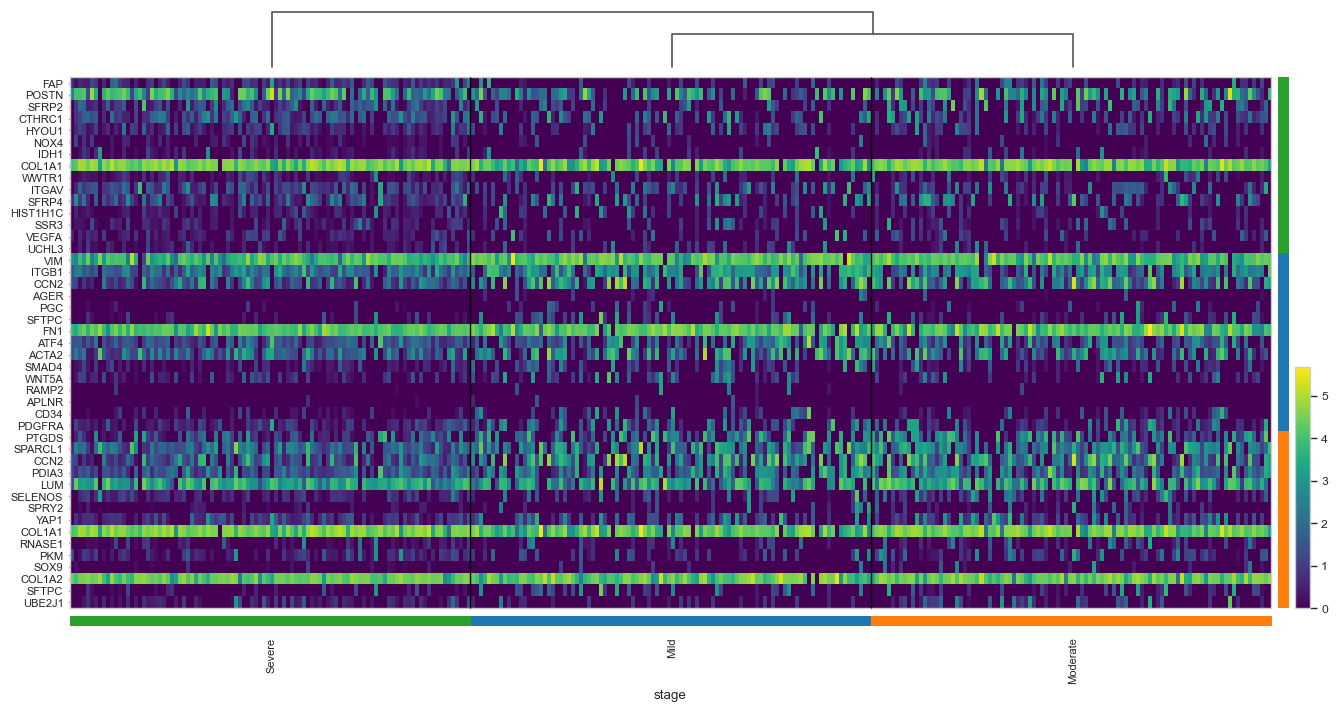

In [28]:
set_vis_default(font = 1.)
sc.tl.rank_genes_groups(adata_de, 
                        groupby = 'stage', 
                        method='wilcoxon', 
                        key_added = "wilcoxon"
                       )
sc.pl.rank_genes_groups_heatmap(adata_de, 
                                n_genes=15, 
                                key="wilcoxon", 
                                groupby="stage", 
                                show_gene_labels=True,
                                use_raw=False, 
#                                 vmin=0, vmax = 3,
                                swap_axes=True,
                                figsize=(16,8),
                                cmap = 'viridis'
                               )

In [29]:
set_vis_default(font = 1.3)

markers = {}
# markers_list = []
for group in adata_de.obs['stage'].unique():
    de_genes = sc.get.rank_genes_groups_df(adata_de, group=group, key = "wilcoxon")

    markers[group] = de_genes['names'].tolist()[:20]
 

/tmp/ipykernel_3454798/1900002615.py:31: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


In [30]:
adata_dot = adata_scaled.copy()
sc.pp.scale(adata_dot)

order = ['Mild', 'Moderate', 'Severe']
adata_dot.obs['stage'] = pd.Categorical(adata_dot.obs['stage'], categories=order, ordered=True)



/tmp/ipykernel_3454798/1900002615.py:31: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')
/home/xwanaf/.conda/envs/scGPT/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


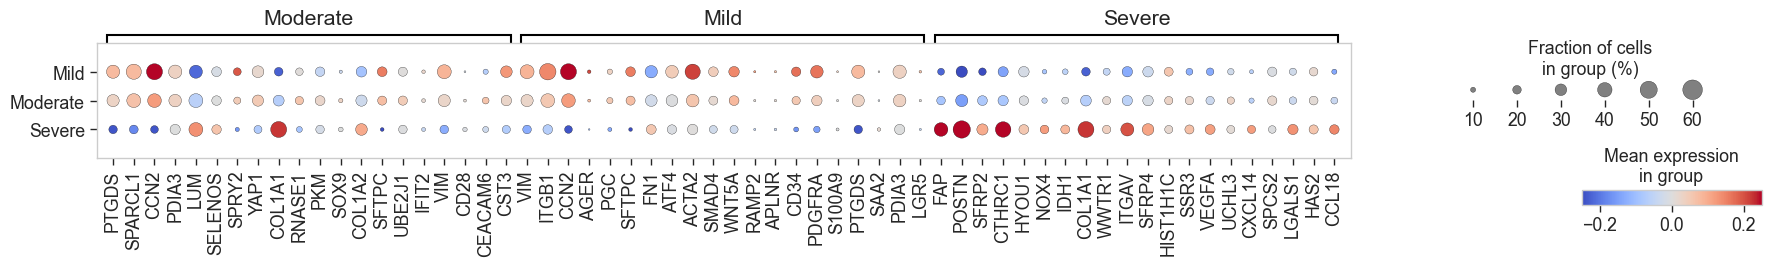

dict_values([['PTGDS', 'SPARCL1', 'CCN2', 'PDIA3', 'LUM', 'SELENOS', 'SPRY2', 'YAP1', 'COL1A1', 'RNASE1', 'PKM', 'SOX9', 'COL1A2', 'SFTPC', 'UBE2J1', 'IFIT2', 'VIM', 'CD28', 'CEACAM6', 'CST3'], ['VIM', 'ITGB1', 'CCN2', 'AGER', 'PGC', 'SFTPC', 'FN1', 'ATF4', 'ACTA2', 'SMAD4', 'WNT5A', 'RAMP2', 'APLNR', 'CD34', 'PDGFRA', 'S100A9', 'PTGDS', 'SAA2', 'PDIA3', 'LGR5'], ['FAP', 'POSTN', 'SFRP2', 'CTHRC1', 'HYOU1', 'NOX4', 'IDH1', 'COL1A1', 'WWTR1', 'ITGAV', 'SFRP4', 'HIST1H1C', 'SSR3', 'VEGFA', 'UCHL3', 'CXCL14', 'SPCS2', 'LGALS1', 'HAS2', 'CCL18']])


In [31]:
set_vis_default(font = 1.6)
sub_dict = markers
dp = sc.pl.dotplot(
    adata_dot, 
    sub_dict, 
    groupby = 'stage', 
    use_raw=None, 
    var_group_rotation = 0,
    expression_cutoff = .5,
    
    dendrogram=False, 
    figsize = (18, 1.5),
    vcenter = 0,
    cmap = 'coolwarm',
    vmin = -.25, vmax = .25,
    swap_axes = False,
    dot_max = 0.6,
    return_fig=True,
#     **{'marker': MarkerStyle("o", fillstyle="top")}
    
)

dp.get_axes()['size_legend_ax'].set_position([0.88, 0.5, 0.15, 0.23])  # [left, bottom, width, height]
dp.get_axes()['color_legend_ax'].set_position([.95, -0.2, 0.1, 0.1])  # [left, bottom, width, height]


sp_color_df = dp.dot_color_df.copy()
sp_size_df = dp.dot_size_df.copy()
yticks_labels = dp.get_axes()['mainplot_ax'].get_yticklabels()
yticks_labels = [_.get_text() for _ in yticks_labels]

# plt.savefig(f'./save_figs/Stage_de_severity.svg', format='svg', dpi = 200, bbox_inches='tight',pad_inches=1)
plt.show()
plt.close()
print(sub_dict.values())

In [32]:
markers = {
    'Mild': ['ACTA2', 'CCN2'],
    'Moderate': ['ITGB1', 'CCL2'],
    'Severe': ['CXCL14', 'FAP']
}

/tmp/ipykernel_3454798/1900002615.py:31: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')
/home/xwanaf/.conda/envs/scGPT/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


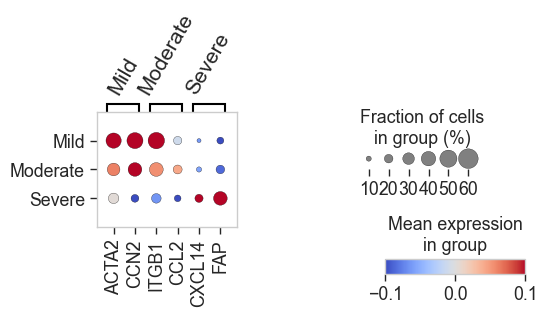

dict_values([['ACTA2', 'CCN2'], ['ITGB1', 'CCL2'], ['CXCL14', 'FAP']])


In [35]:
set_vis_default(font = 1.6)
sub_dict = markers
dp = sc.pl.dotplot(
    adata_dot, 
    sub_dict, 
    groupby = 'stage', 
    use_raw=None, 
    var_group_rotation = 60,
    expression_cutoff = .5,
    
    dendrogram=False, 
    figsize = (3.5, 1.5),
    vcenter = 0,
    cmap = 'coolwarm',
    vmin = -.1, vmax = .1,
    swap_axes = False,
    dot_max = 0.6,
    return_fig=True,
#     **{'marker': MarkerStyle("o", fillstyle="top")}
    
)

dp.get_axes()['size_legend_ax'].set_position([0.88, 0.5, 0.35, 0.23])  # [left, bottom, width, height]
dp.get_axes()['color_legend_ax'].set_position([.95, -0.2, 0.4, 0.1])  # [left, bottom, width, height]


sp_color_df = dp.dot_color_df.copy()
sp_size_df = dp.dot_size_df.copy()
yticks_labels = dp.get_axes()['mainplot_ax'].get_yticklabels()
yticks_labels = [_.get_text() for _ in yticks_labels]

# plt.savefig(f'./save_figs/nrb_expr_de.svg', format='svg', dpi = 200, bbox_inches='tight',pad_inches=1)
plt.show()
plt.close()
print(sub_dict.values())

## further check by scatter plot

/tmp/ipykernel_3454798/1900002615.py:31: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')
/tmp/ipykernel_3454798/1434314968.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('Spectral').reversed()


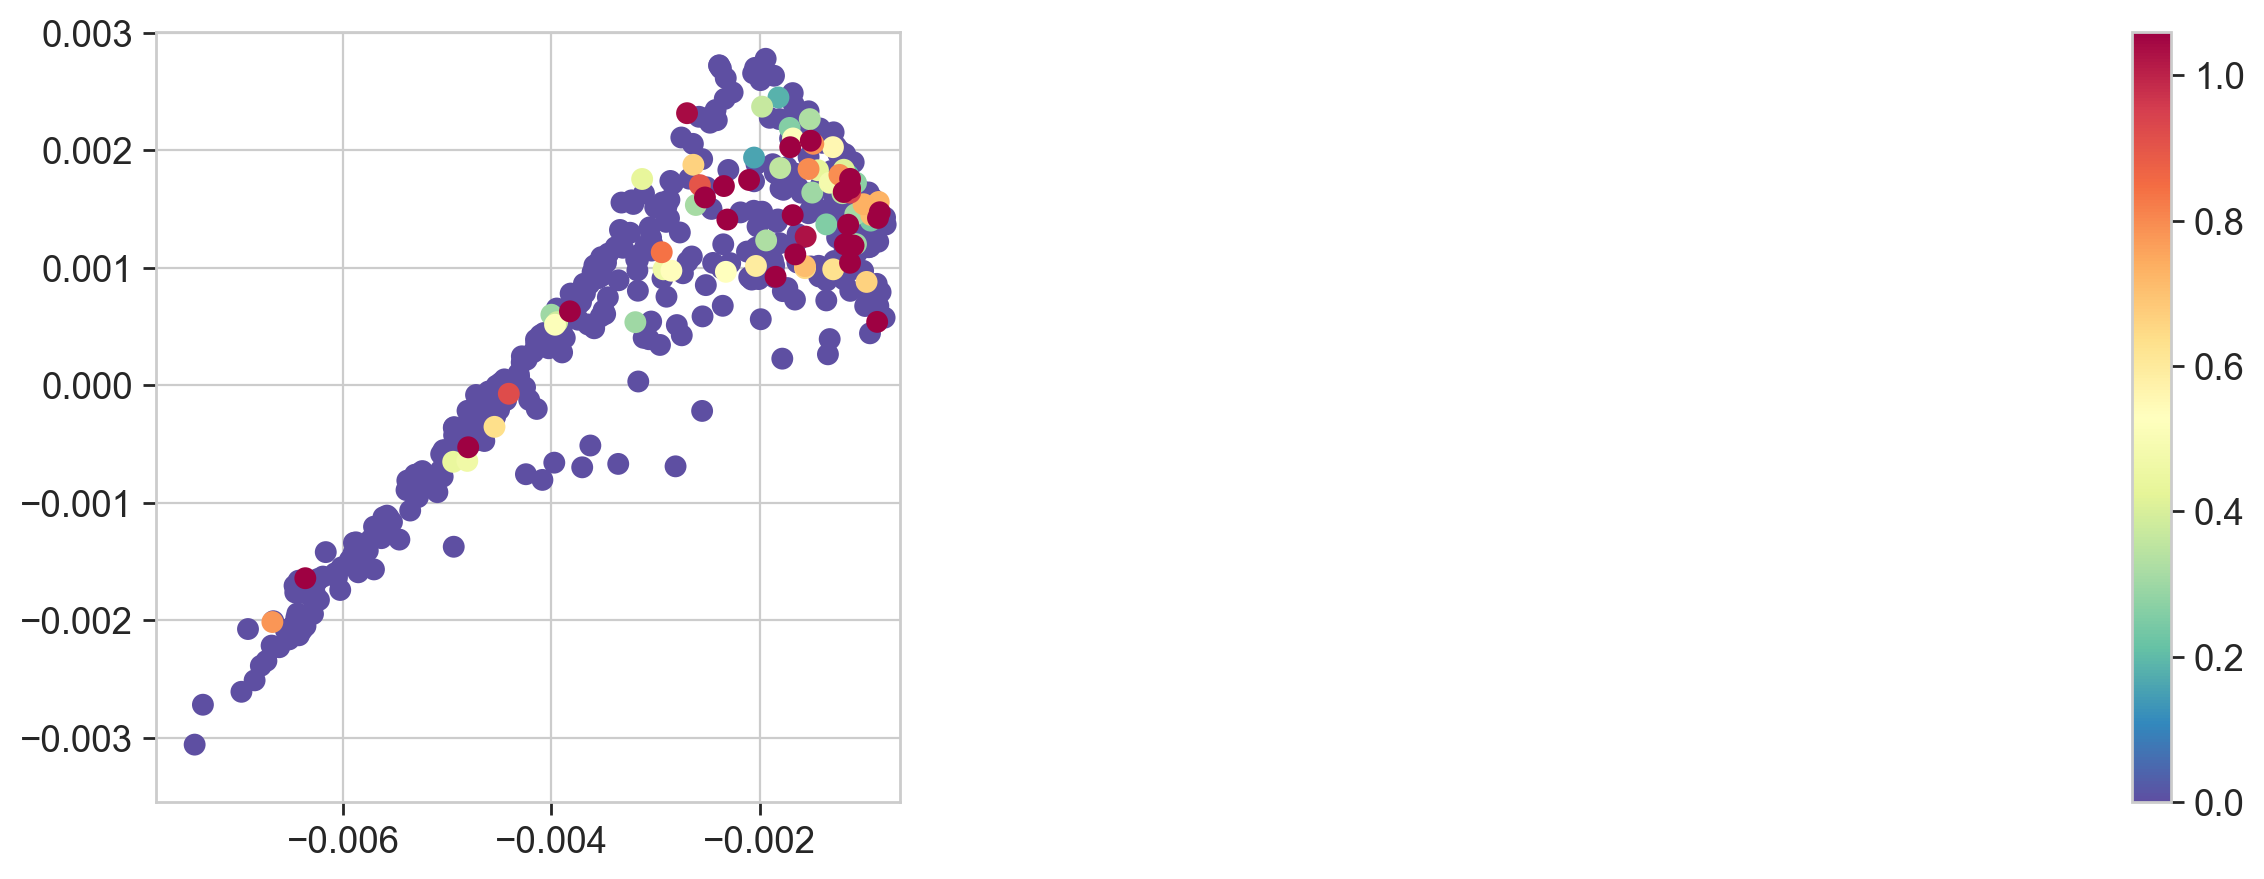

In [76]:
set_vis_default(font = 1.5)

adata = adata_scaled
fig, axs = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'wspace': .5, 'hspace': 0.2}, dpi = 200)
X_diffmap_vis = adata.obsm['X_diffmap'][:, [1,2]]
X_diffmap_all = adata_scaled.obsm['X_diffmap'][:, [1,2]]


# 'ICAM1', 'XBP1', 'RNASE1', 'MSLN', 'GKN2', 'HLA-DRA',
float_values = adata[:, 'CXCL14'].X.squeeze()
reorder_index = np.argsort(float_values)
cmap = cm.get_cmap('Spectral').reversed()

norm = plt.Normalize(vmin=np.quantile(float_values, .05), vmax=np.quantile(float_values, .95))
colors = cmap(norm(float_values))

index = reorder_index
reorder_index = reorder_index[np.sort(np.random.choice(len(reorder_index), 500, replace=False))]

axs[0].scatter(
    X_diffmap_vis[reorder_index][:, 0], X_diffmap_vis[reorder_index][:, 1], 
    s = 50, color=colors[reorder_index], alpha = 1.,
#     vmax = 3
) 


for i in range(2):
    axs[i].set_xlim([X_diffmap_all[:, 0].min(), X_diffmap_all[:, 0].max()])
    axs[i].set_ylim([X_diffmap_all[:, 1].min(), X_diffmap_all[:, 1].max()])

cbar = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=axs)

axs[1].remove()


plt.show()
plt.close()

# Mph

### Expr of neighbor Monocyte-derived_Mph

In [77]:
nrb_expr_path = './spatial_nrb_src/output'
nrb_expr_path = Path(nrb_expr_path)
os.listdir(nrb_expr_path)

adata_nrb = sc.read(nrb_expr_path / 'nrb_expr_raw_Monocyte-derived_Mph.h5ad')


In [78]:
adata_nrb_index = adata_nrb.obs.index[adata_nrb.obs.index.isin(adata_sp_time.obs.index)]
adata_nrb = adata_nrb[adata_nrb_index].copy()
adata_nrb.obs['time'] = adata_sp_time.obs.loc[adata_nrb.obs.index]['time']
adata_nrb.obsm['X_diffmap'] = adata_sp_time[adata_nrb.obs.index].obsm['X_diffmap']
adata_nrb

AnnData object with n_obs × n_vars = 19011 × 337
    obs: 'sample', 'nrb_ct', 'time'
    obsm: 'X_diffmap'

# Divide stages

/tmp/ipykernel_3454798/1900002615.py:31: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')
/tmp/ipykernel_3454798/3224106280.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('Spectral').reversed()


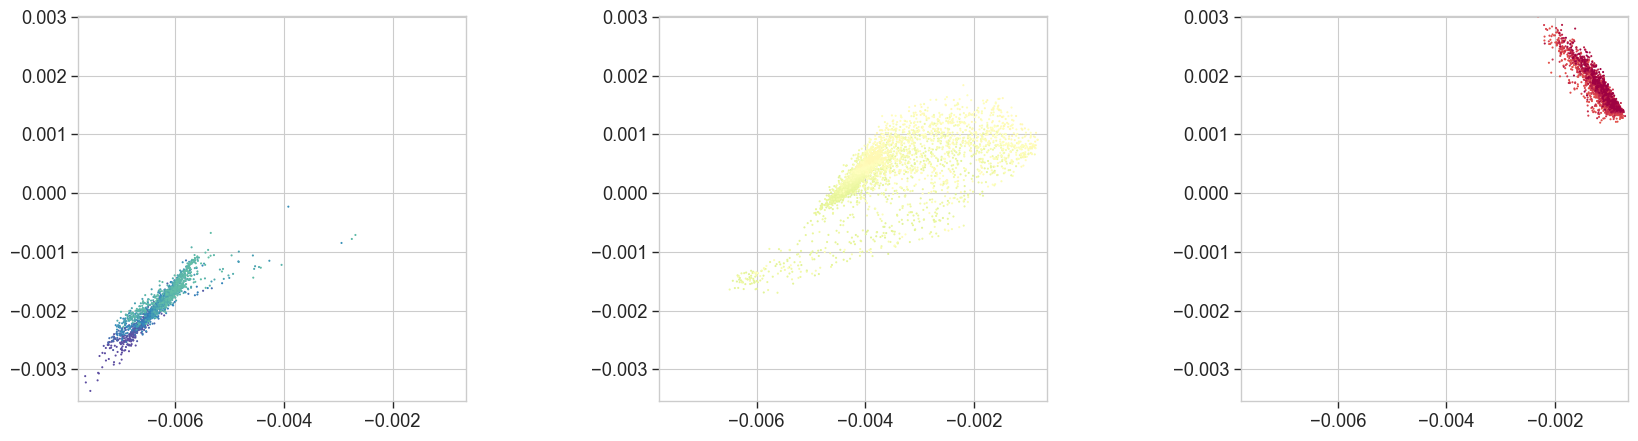

In [79]:
from matplotlib import cm
set_vis_default(font = 1.5)

fig, axs = plt.subplots(1, 3, figsize=(20, 5), gridspec_kw={'wspace': .5, 'hspace': 0.2})
X_diffmap_vis = adata_sp_time.obsm['X_diffmap'][:, [1,2]]
reorder_index = np.argsort(adata_sp_time.obs['time'])

# float_values = adata_sp_time[:, 'ICAM1'].X.A.squeeze()
float_values = adata_sp_time.obs['time']
# cmap = cm.get_cmap('viridis')
cmap = cm.get_cmap('Spectral').reversed()
norm = plt.Normalize(vmin=0.26, vmax=np.quantile(float_values, .99))
colors = cmap(norm(float_values))

index = reorder_index

time_index = (adata_sp_time.obs['time'] <= .35)[reorder_index] #& (adata_sp_time.obs['time'] >= 0.6)
Early_index = adata_sp_time[reorder_index][time_index].obs.index
axs[0].scatter(
    X_diffmap_vis[index][:, 0][time_index], X_diffmap_vis[index][:, 1][time_index], 
    s = .5, color=colors[index][time_index]
) 
time_index = ((adata_sp_time.obs['time'] > .44) & (adata_sp_time.obs['time'] < .5))[reorder_index] #& (adata_sp_time.obs['time'] >= 0.6)
Median_index = adata_sp_time[reorder_index][time_index].obs.index
axs[1].scatter(
    X_diffmap_vis[index][:, 0][time_index], X_diffmap_vis[index][:, 1][time_index], 
    s = .5, color=colors[index][time_index]
)
time_index = (adata_sp_time.obs['time'] > .65)[reorder_index] #& (adata_sp_time.obs['time'] >= 0.6)
Late_index = adata_sp_time[reorder_index][time_index].obs.index
axs[2].scatter(
    X_diffmap_vis[index][:, 0][time_index], X_diffmap_vis[index][:, 1][time_index], 
    s = .5, color=colors[index][time_index]
)

for i in range(3):
    axs[i].set_xlim([X_diffmap_vis[:, 0].min(), X_diffmap_vis[:, 0].max()])
    axs[i].set_ylim([X_diffmap_vis[:, 1].min(), X_diffmap_vis[:, 1].max()])
plt.show()
plt.close()


In [80]:
adata_scaled = adata_nrb.copy()

###### assign stage label
Group = np.empty(adata_scaled.shape[0], dtype = object)
Group[adata_scaled.obs.index.isin(list(Early_index))] = 'Mild'
Group[adata_scaled.obs.index.isin(list(Median_index))] = 'Moderate'
Group[adata_scaled.obs.index.isin(list(Late_index))] = 'Severe'
adata_scaled.obs['stage'] = Group


# sc.pp.scale(adata_scaled)

In [84]:
adata_scaled.obs['stage'].value_counts()

stage
Moderate    3420
Severe      1693
Mild        1240
Name: count, dtype: int64

In [89]:
adata_de = adata_scaled.copy()
adata_de = adata_de[[_ is not None for _ in adata_de.obs['stage']]]
# adata_de = subsample_cluster(
#     adata_de, 
#     subsample_col = 'stage', 
#     max_cellnum = 1000,
#     show_res = True
# ).copy()

/tmp/ipykernel_3454798/1900002615.py:31: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')
/home/xwanaf/.conda/envs/scGPT/lib/python3.8/site-packages/anndata/_core/anndata.py:1230: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


         Falling back to preprocessing with `sc.pp.pca` and default params.


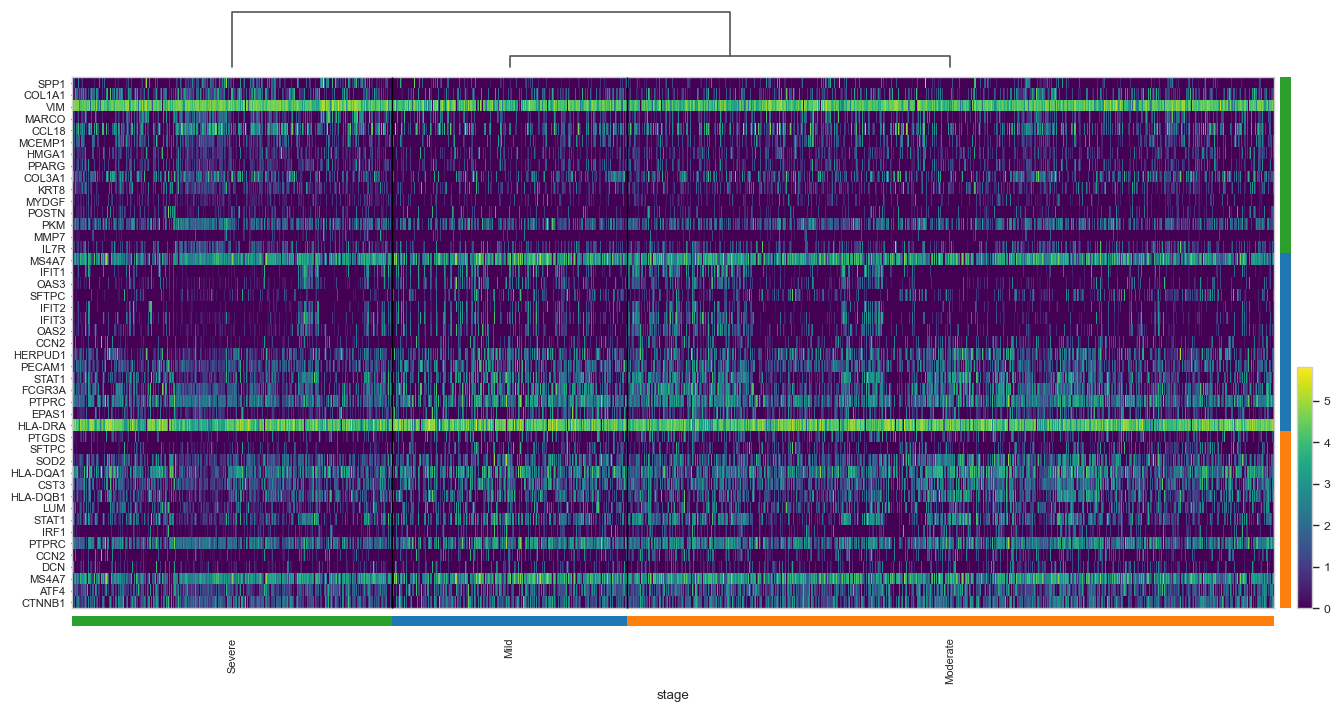

In [90]:
set_vis_default(font = 1.)
sc.tl.rank_genes_groups(adata_de, 
                        groupby = 'stage', 
                        method='wilcoxon', 
                        key_added = "wilcoxon"
                       )
sc.pl.rank_genes_groups_heatmap(adata_de, 
                                n_genes=15, 
                                key="wilcoxon", 
                                groupby="stage", 
                                show_gene_labels=True,
                                use_raw=False, 
#                                 vmin=0, vmax = 3,
                                swap_axes=True,
                                figsize=(16,8),
                                cmap = 'viridis'
                               )

In [91]:
set_vis_default(font = 1.3)

markers = {}
# markers_list = []
for group in adata_de.obs['stage'].unique():
    de_genes = sc.get.rank_genes_groups_df(adata_de, group=group, key = "wilcoxon")

    markers[group] = de_genes['names'].tolist()[:20]
 

/tmp/ipykernel_3454798/1900002615.py:31: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


In [92]:
adata_dot = adata_scaled.copy()
sc.pp.scale(adata_dot)

order = ['Mild', 'Moderate', 'Severe']
adata_dot.obs['stage'] = pd.Categorical(adata_dot.obs['stage'], categories=order, ordered=True)



/tmp/ipykernel_3454798/1900002615.py:31: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')
/home/xwanaf/.conda/envs/scGPT/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


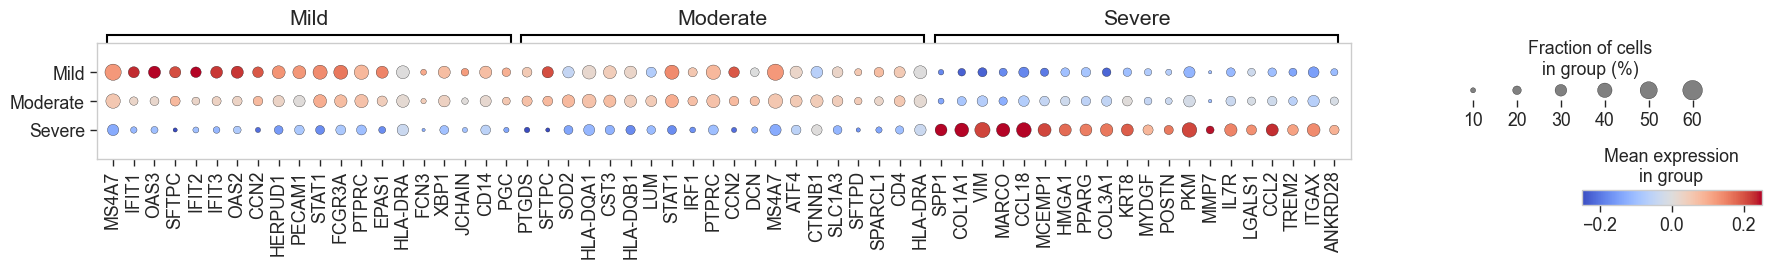

dict_values([['MS4A7', 'IFIT1', 'OAS3', 'SFTPC', 'IFIT2', 'IFIT3', 'OAS2', 'CCN2', 'HERPUD1', 'PECAM1', 'STAT1', 'FCGR3A', 'PTPRC', 'EPAS1', 'HLA-DRA', 'FCN3', 'XBP1', 'JCHAIN', 'CD14', 'PGC'], ['PTGDS', 'SFTPC', 'SOD2', 'HLA-DQA1', 'CST3', 'HLA-DQB1', 'LUM', 'STAT1', 'IRF1', 'PTPRC', 'CCN2', 'DCN', 'MS4A7', 'ATF4', 'CTNNB1', 'SLC1A3', 'SFTPD', 'SPARCL1', 'CD4', 'HLA-DRA'], ['SPP1', 'COL1A1', 'VIM', 'MARCO', 'CCL18', 'MCEMP1', 'HMGA1', 'PPARG', 'COL3A1', 'KRT8', 'MYDGF', 'POSTN', 'PKM', 'MMP7', 'IL7R', 'LGALS1', 'CCL2', 'TREM2', 'ITGAX', 'ANKRD28']])


In [93]:
set_vis_default(font = 1.6)
sub_dict = markers
dp = sc.pl.dotplot(
    adata_dot, 
    sub_dict, 
    groupby = 'stage', 
    use_raw=None, 
    var_group_rotation = 0,
    expression_cutoff = .5,
    
    dendrogram=False, 
    figsize = (18, 1.5),
    vcenter = 0,
    cmap = 'coolwarm',
    vmin = -.25, vmax = .25,
    swap_axes = False,
    dot_max = 0.6,
    return_fig=True,
#     **{'marker': MarkerStyle("o", fillstyle="top")}
    
)

dp.get_axes()['size_legend_ax'].set_position([0.88, 0.5, 0.15, 0.23])  # [left, bottom, width, height]
dp.get_axes()['color_legend_ax'].set_position([.95, -0.2, 0.1, 0.1])  # [left, bottom, width, height]


sp_color_df = dp.dot_color_df.copy()
sp_size_df = dp.dot_size_df.copy()
yticks_labels = dp.get_axes()['mainplot_ax'].get_yticklabels()
yticks_labels = [_.get_text() for _ in yticks_labels]

# plt.savefig(f'./save_figs/Stage_de_severity.svg', format='svg', dpi = 200, bbox_inches='tight',pad_inches=1)
plt.show()
plt.close()
print(sub_dict.values())

In [94]:
markers = {
    'Mild': ['IFIT2'],
    'Moderate': ['PTGDS', 'IL1B'],
    'Severe': ['SPP1']
}

/tmp/ipykernel_3454798/1900002615.py:31: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')
/home/xwanaf/.conda/envs/scGPT/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


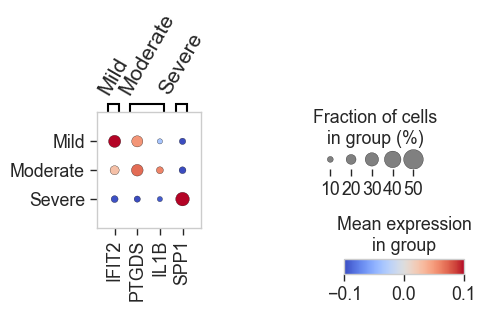

dict_values([['IFIT2'], ['PTGDS', 'IL1B'], ['SPP1']])


In [95]:
set_vis_default(font = 1.6)
sub_dict = markers
dp = sc.pl.dotplot(
    adata_dot, 
    sub_dict, 
    groupby = 'stage', 
    use_raw=None, 
    var_group_rotation = 60,
    expression_cutoff = .5,
    
    dendrogram=False, 
    figsize = (3, 1.5),
    vcenter = 0,
    cmap = 'coolwarm',
    vmin = -.1, vmax = .1,
    swap_axes = False,
    dot_max = 0.5,
    return_fig=True,
#     **{'marker': MarkerStyle("o", fillstyle="top")}
    
)

dp.get_axes()['size_legend_ax'].set_position([0.88, 0.5, 0.35, 0.23])  # [left, bottom, width, height]
dp.get_axes()['color_legend_ax'].set_position([.95, -0.2, 0.4, 0.1])  # [left, bottom, width, height]


sp_color_df = dp.dot_color_df.copy()
sp_size_df = dp.dot_size_df.copy()
yticks_labels = dp.get_axes()['mainplot_ax'].get_yticklabels()
yticks_labels = [_.get_text() for _ in yticks_labels]

# plt.savefig(f'./save_figs/nrb_expr_de_Mph.svg', format='svg', dpi = 200, bbox_inches='tight',pad_inches=1)
plt.show()
plt.close()
print(sub_dict.values())

/tmp/ipykernel_3454798/1900002615.py:31: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')
/tmp/ipykernel_3454798/2170855157.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('Spectral').reversed()


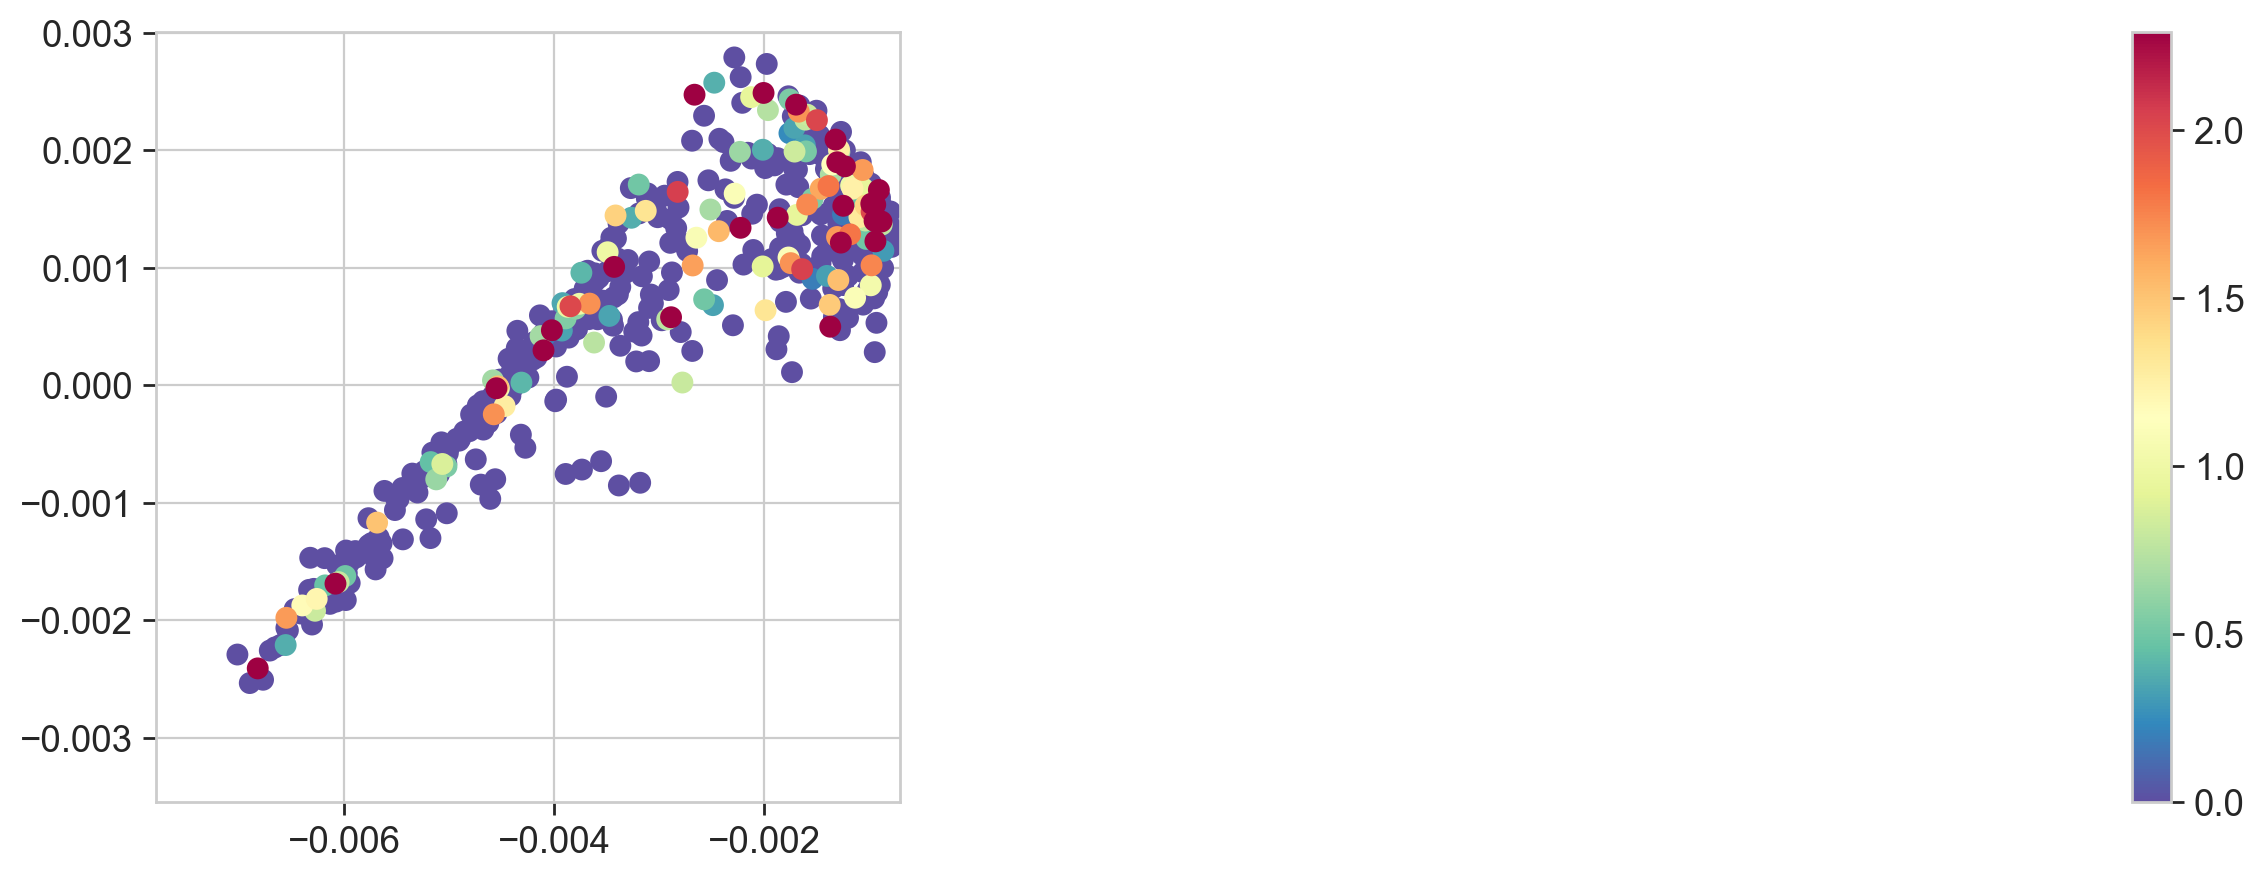

In [96]:
set_vis_default(font = 1.5)

adata = adata_scaled
fig, axs = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'wspace': .5, 'hspace': 0.2}, dpi = 200)
X_diffmap_vis = adata.obsm['X_diffmap'][:, [1,2]]
X_diffmap_all = adata_scaled.obsm['X_diffmap'][:, [1,2]]


# 'ICAM1', 'XBP1', 'RNASE1', 'MSLN', 'GKN2', 'HLA-DRA',
float_values = adata[:, 'SPP1'].X.squeeze()
reorder_index = np.argsort(float_values)
cmap = cm.get_cmap('Spectral').reversed()

norm = plt.Normalize(vmin=np.quantile(float_values, .05), vmax=np.quantile(float_values, .95))
colors = cmap(norm(float_values))

index = reorder_index
reorder_index = reorder_index[np.sort(np.random.choice(len(reorder_index), 500, replace=False))]

axs[0].scatter(
    X_diffmap_vis[reorder_index][:, 0], X_diffmap_vis[reorder_index][:, 1], 
    s = 50, color=colors[reorder_index], alpha = 1.,
#     vmax = 3
) 


for i in range(2):
    axs[i].set_xlim([X_diffmap_all[:, 0].min(), X_diffmap_all[:, 0].max()])
    axs[i].set_ylim([X_diffmap_all[:, 1].min(), X_diffmap_all[:, 1].max()])

cbar = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=axs)

axs[1].remove()


plt.show()
plt.close()